# Solve viscous Burgers equation with Frozen-PINN-swim:
In this script we show how Frozen-PINN-swim uses resampling of collocation points and data-dependant sampling of weights and biases to solve Burgers equation accurately

In [1]:
import sys
sys.path.append('../../')
sys.path.append('../../src')
from swimpde.domain import ResamplingDomain
from adaptive_swim.ansatz import BasicAnsatz
from swimpde.solver import TimeDependentSolver
from swimpde.equation import Burgers
import numpy as np
import scipy
import time
import matplotlib.pyplot as plt
plt.rcParams['image.cmap'] = 'jet'
from utils import compute_relative_l2_error, plot_spatiotemporal_solutions, plot_temporal_slices, compute_metrics


### Load data and reference solution

In [2]:
# Load and visualize data
data = scipy.io.loadmat('data/burgers_shock.mat')
t_eval = data['t'].flatten()[:,None]
x_eval = data['x'].flatten()[:,None]
u_exact = np.real(data['usol']).T
X, T = np.meshgrid(x_eval,t_eval)
X_ = np.hstack((X.flatten()[:,None], T.flatten()[:,None]))

# Set ground truth
u_true = u_exact.flatten()[:,None]             

### Problem setup

In [3]:
# initial condition
def u0(x):
    return -1 * np.sin(np.pi * x)

# forcing
def forcing(x, t):
    return np.zeros(x.shape[0])

# boundary condition
boundary_condition = "zero dirichlet" # 

# Domain information and spacial points for the first time-block
n_points_1d = 4000 # No. of points in space
x_lim = [-1, 1] # Domain range

# Interior points
rng = np.random.default_rng(seed=123)
x_space = rng.uniform(x_lim[0], x_lim[1], n_points_1d).reshape((-1, 1)) 
x_space_inner = x_space[1:-1]
interior_points = x_space_inner

# Boundary points (excluding corners)
left = x_lim[0]
right = x_lim[1]
boundary_points = np.row_stack([left, right])

/var/folders/q0/trwlbpyx2sn3p0dddjc7fvkw0000gn/T/ipykernel_90311/3795381570.py:25: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  boundary_points = np.row_stack([left, right])


### Train and evaluate Frozen-PINN-swim network
Note: The runtime increases if plot_collocation_points = True, so for runtime measurements, set it to False. 

In [4]:
# Hyper-parameters

# config_accuracy: Frozen-PINN-swim with high accuracy
config_accuracy = {
    "n_sample": 4000,                 #  No. of sampling points (for computing gradients)
    "width": 600,                     # Width
    "reg_const": 1e-13,               # Regularization constant
    "svd_cutoff": 5e-11,              # SVD threshold
    "tol": 1e-6,                      # Tolerance
    "time_blocks": 9,                 # Number of time-blocks for sampling
}

# config_speed: Frozen-PINN-swim with high speed for an accuracy comparable to vanilla PINN
config_speed = {
    "n_sample": 1000,                 # No. of sampling points (for computing gradients)
    "width": 300,                     # Width
    "reg_const": 1e-8,                # Regularization constant
    "svd_cutoff": 1e-8,               # SVD threshold
    "tol": 1e-6,                      # Tolerance
    "time_blocks": 9,                 # Number of time-blocks for samplings
}

# Choose the configuration
config = config_speed


info = [] # List to store errors and time measurements
seeds = [1, 2, 3]          # Seeds to compute mean errors
seed = 1

# Define prob. distribution for (re)-sampling collocation points
def collocation_points_probabilities(df_dx):
    gradients = np.abs(df_dx)
    gradients = gradients + 0.03 * np.max(gradients)
    return gradients/np.sum(gradients)

# Points where gradient of the solution at the end of a time-block is computed
sample_test_points = np.linspace(x_lim[0] + 1e-6, x_lim[1] - 1e-6, config["n_sample"]).reshape((-1, 1)) # This does not include boundary points

# Domain
domain = ResamplingDomain(
    interior_points=interior_points,
    boundary_points=boundary_points,
    sample_points = sample_test_points,
    resampling_pdf=collocation_points_probabilities,
    random_seed=seed,
)

In [5]:
ansatz = BasicAnsatz(
    n_basis=config["width"],
    activation="rational",
    random_seed=seed,
    initial_condition=u0,
    svd_cutoff=config["svd_cutoff"],
    repetition_scaler=1,
    k=40,
    s=0.5,
)

equation = Burgers(u0=u0, nu=0.01/np.pi)

# Define the solver.
solver = TimeDependentSolver(
    domain=domain,
    ansatz=ansatz,
    forcing=forcing,
    forced_boundary_condition=boundary_condition,
    equation=equation,
    regularization_scale=config["reg_const"],
    rtol=config["tol"],
    atol=config["tol"],
    ode_solver='LSODA',
    resample_domain=True,
)

# Fit the solver.
start_fit = time.time()
solver.fit(t_span=[0, np.max(t_eval)], n_time_blocks=config["time_blocks"])
end_fit = time.time()
training_time = end_fit - start_fit

print(f"Training time: {training_time:.4f}s")

Training time: 24.2439s


(3998, 1)


Text(0, 0.5, 't')

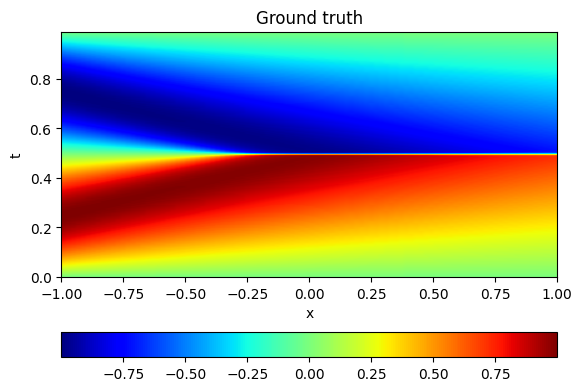

In [6]:
print(domain.interior_points.shape)
# Visualize the solution.
fig, ax = plt.subplots(1)
extent = [x_eval.min(), x_eval.max(), t_eval.min(), t_eval.max()]
im = ax.imshow(u_exact.T, extent=extent, origin="lower")
fig.colorbar(im, ax=ax, orientation="horizontal");
ax.set_title("Ground truth")
ax.set_xlabel("x")
ax.set_ylabel("t")

Relative error: 1.940E-06


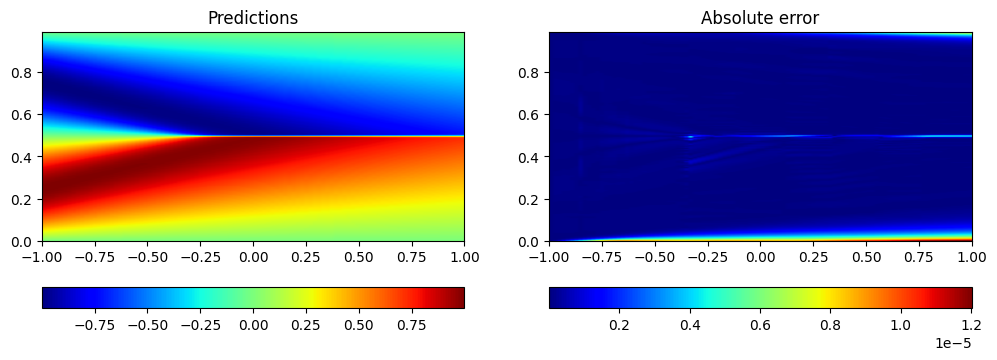

In [7]:
u_pred = solver.evaluate(x_eval, t_eval).T
abs_error, rel_l2_error = compute_metrics(u_pred, u_exact)

print(fr"Relative error: {rel_l2_error:.3E}")

fig, axes_full = plt.subplots(1, 2, figsize=(12, 4))

# Plot solutions for all t.
data_dict = {
    "Predictions": u_pred,
    "Absolute error": abs_error,
}
extent = [x_eval.min(), x_eval.max(), t_eval.min(), t_eval.max()]
for ax, (label, data) in zip(axes_full, data_dict.items()):
    im = ax.imshow(data.T, extent=extent, origin="lower")
    fig.colorbar(im, ax=ax, location="bottom")
    ax.set_title(label)


Relative L2 error on the entire spatio-temporal domain: 1.939656e-06


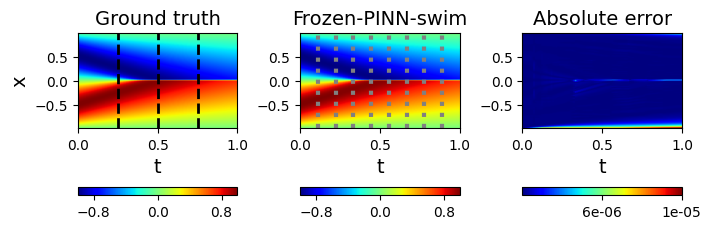

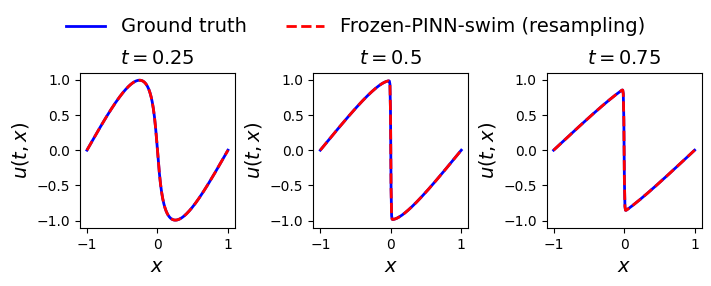

In [8]:
u_true_test = u_exact
u_model_test = u_pred

error_u = compute_relative_l2_error(u_exact.reshape(-1, 1), u_model_test)
print('Relative L2 error on the entire spatio-temporal domain: %e' % error_u)

plot_spatiotemporal_solutions(u_true_test, u_model_test, x_space)
plot_temporal_slices(u_exact, u_model_test, x_eval)
